# lien de github
https://github.com/ISMHH06/Technique-AI

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Data Generation & Visualization

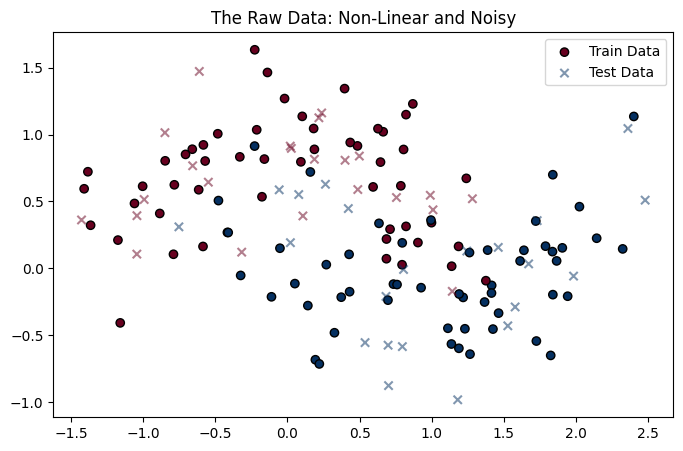

In [2]:
# Generate noisy data
x, y = make_moons(n_samples=150, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data')
plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()

### Polynomial Features (Degree 10)

In [3]:
# create polynomial features
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

### Logistic Regression – No Regularization

In [4]:
# Create a pipeline with polynomial features and logistic regression
from sklearn.pipeline import make_pipeline
model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X_train_poly, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test_poly)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with Polynomial Features: {accuracy:.2f}")

Accuracy with Polynomial Features: 0.84


### Decision Boundary Function

In [5]:
# visualize the decision boundary
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = model.predict(poly.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdBu')
    plt.title("Decision Boundary with Polynomial Features")
    plt.show()

### Decision Boundary – No Regularization

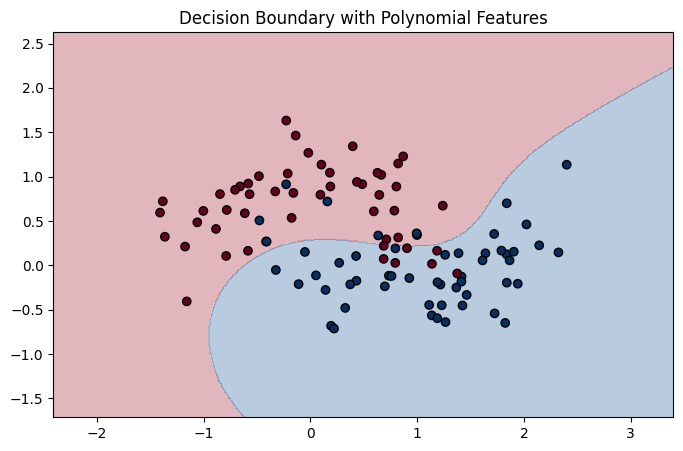

In [6]:
plot_decision_boundary(model, X_train, y_train)

### Logistic Regression – L1 Regularization

In [7]:
# create a pipeline for polynomial features and logistic regression with L1 optimization
model1 = make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', solver='liblinear'))
model1.fit(X_train_poly, y_train)
# Predict and evaluate the model
y_pred1 = model1.predict(X_test_poly)
accuracy1 = accuracy_score(y_test, y_pred1)
print(f"Accuracy with L1 Regularization: {accuracy1:.2f}")

Accuracy with L1 Regularization: 0.84


### Decision Boundary – L1 Regularization

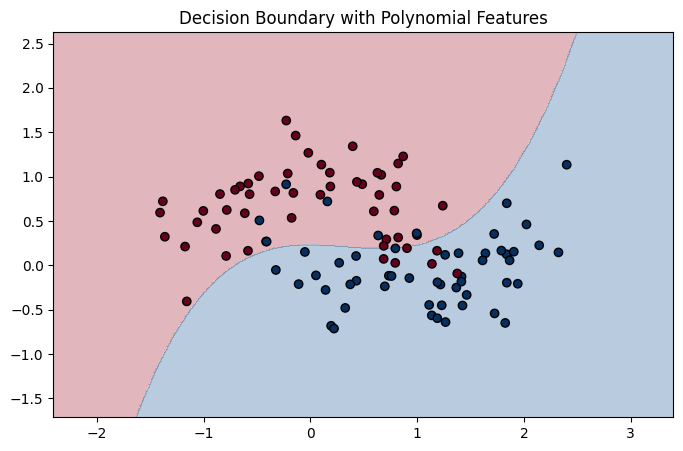

In [8]:
# visualize the decision boundary for L1 optimization
plot_decision_boundary(model1, X_train, y_train)

### Logistic Regression – L2 Regularization

In [9]:
# create a pipeline for polynomial features and logistic regression with L2 optimization
model2 = make_pipeline(StandardScaler(), LogisticRegression(penalty='l2', solver='liblinear'))
model2.fit(X_train_poly, y_train)
# Predict and evaluate the model
y_pred2 = model2.predict(X_test_poly)
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Accuracy with L2 Regularization: {accuracy2:.2f}")

Accuracy with L2 Regularization: 0.84


### Decision Boundary – L2 Regularization

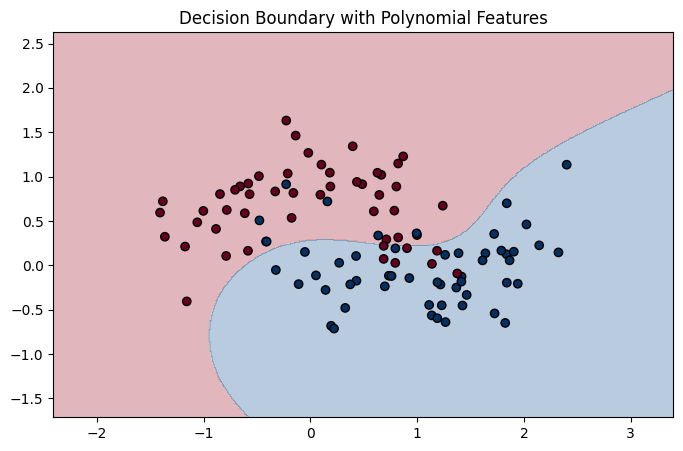

In [10]:
# visualize the decision boundary for L2 optimization
plot_decision_boundary(model2, X_train, y_train)

### High-Dimensional Data Generation

In [11]:
# Generate data with 3K samples and 50 features with make_classification
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=3000, n_features=50, n_informative=10, n_redundant=10, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((2100, 50), (900, 50), (2100,), (900,))

### High-Dimensional Data Visualization

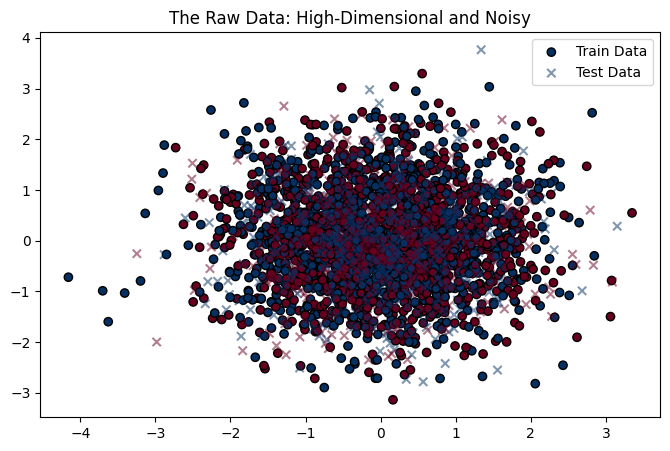

In [12]:
# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data')
plt.title("The Raw Data: High-Dimensional and Noisy")
plt.legend()
plt.show()

### Degree 2 – Polynomial Features

In [13]:
# ── Degree 2: Polynomial Features ──────────────────────────────────────────
n_epochs = 200

poly2 = PolynomialFeatures(degree=2)
X_train_p2 = poly2.fit_transform(X_train)
X_test_p2  = poly2.transform(X_test)

scaler2 = StandardScaler()
X_train_s2 = scaler2.fit_transform(X_train_p2)
X_test_s2  = scaler2.transform(X_test_p2)

print(f'Degree 2 → train shape: {X_train_s2.shape}, test shape: {X_test_s2.shape}')


Degree 2 → train shape: (2100, 1326), test shape: (900, 1326)


### Degree 2 – No Regularization

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

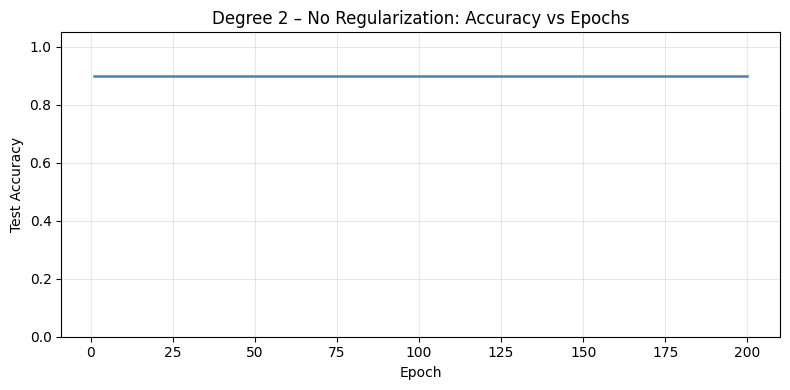

Final accuracy (No Reg, Degree 2): 0.8978


In [14]:
# ── Degree 2 – No Regularization (epoch by epoch) ───────────────────────────
clf_noreg2 = LogisticRegression(penalty='l2', C=1e6, solver='liblinear',
                                  warm_start=True, max_iter=1)
acc_noreg2 = []

for epoch in range(n_epochs):
    clf_noreg2.fit(X_train_s2, y_train)
    acc_noreg2.append(accuracy_score(y_test, clf_noreg2.predict(X_test_s2)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), acc_noreg2, color='steelblue', linewidth=1.8)
plt.title('Degree 2 – No Regularization: Accuracy vs Epochs')
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Final accuracy (No Reg, Degree 2): {acc_noreg2[-1]:.4f}')


### Degree 2 – L1 Regularization

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

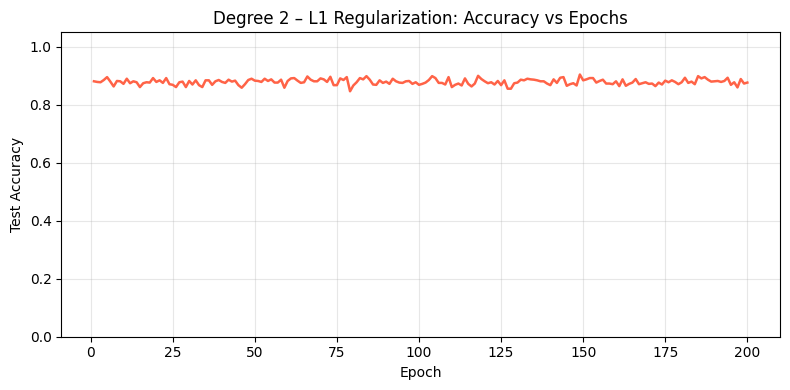

Final accuracy (L1, Degree 2): 0.8767


In [15]:
# ── Degree 2 – L1 Regularization (epoch by epoch) ───────────────────────────
clf_l1_2 = LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                               warm_start=True, max_iter=1)
acc_l1_2 = []

for epoch in range(n_epochs):
    clf_l1_2.fit(X_train_s2, y_train)
    acc_l1_2.append(accuracy_score(y_test, clf_l1_2.predict(X_test_s2)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), acc_l1_2, color='tomato', linewidth=1.8)
plt.title('Degree 2 – L1 Regularization: Accuracy vs Epochs')
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Final accuracy (L1, Degree 2): {acc_l1_2[-1]:.4f}')


### Degree 2 – L2 Regularization

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

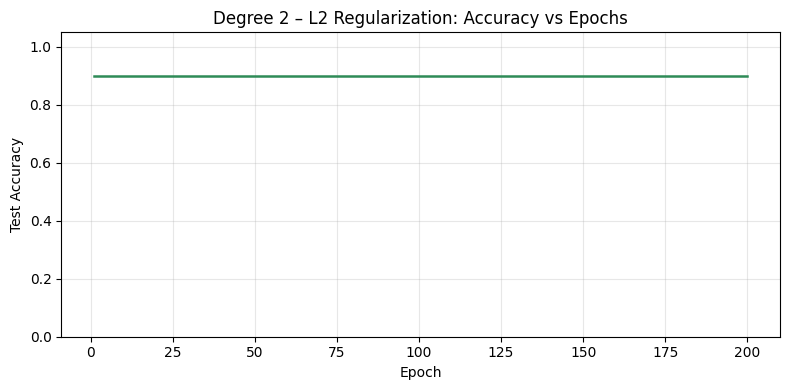

Final accuracy (L2, Degree 2): 0.8989


In [16]:
# ── Degree 2 – L2 Regularization (epoch by epoch) ───────────────────────────
clf_l2_2 = LogisticRegression(penalty='l2', C=1.0, solver='liblinear',
                               warm_start=True, max_iter=1)
acc_l2_2 = []

for epoch in range(n_epochs):
    clf_l2_2.fit(X_train_s2, y_train)
    acc_l2_2.append(accuracy_score(y_test, clf_l2_2.predict(X_test_s2)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), acc_l2_2, color='seagreen', linewidth=1.8)
plt.title('Degree 2 – L2 Regularization: Accuracy vs Epochs')
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Final accuracy (L2, Degree 2): {acc_l2_2[-1]:.4f}')


### Degree 3 – Polynomial Features

In [17]:
# ── Degree 3: Polynomial Features ──────────────────────────────────────────
poly3 = PolynomialFeatures(degree=3)
X_train_p3 = poly3.fit_transform(X_train)
X_test_p3  = poly3.transform(X_test)

scaler3 = StandardScaler()
X_train_s3 = scaler3.fit_transform(X_train_p3)
X_test_s3  = scaler3.transform(X_test_p3)

print(f'Degree 3 → train shape: {X_train_s3.shape}, test shape: {X_test_s3.shape}')


Degree 3 → train shape: (2100, 23426), test shape: (900, 23426)


### Degree 3 – No Regularization

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

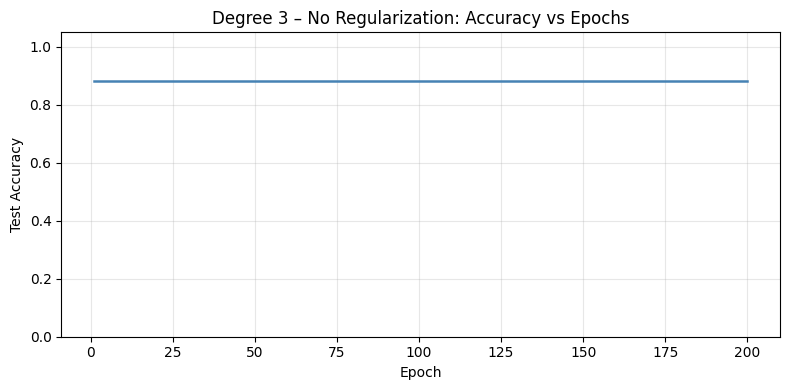

Final accuracy (No Reg, Degree 3): 0.8811


In [18]:
# ── Degree 3 – No Regularization (epoch by epoch) ───────────────────────────
clf_noreg3 = LogisticRegression(penalty='l2', C=1e6, solver='liblinear',
                                  warm_start=True, max_iter=1)
acc_noreg3 = []

for epoch in range(n_epochs):
    clf_noreg3.fit(X_train_s3, y_train)
    acc_noreg3.append(accuracy_score(y_test, clf_noreg3.predict(X_test_s3)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), acc_noreg3, color='steelblue', linewidth=1.8)
plt.title('Degree 3 – No Regularization: Accuracy vs Epochs')
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Final accuracy (No Reg, Degree 3): {acc_noreg3[-1]:.4f}')


### Degree 3 – L1 Regularization

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

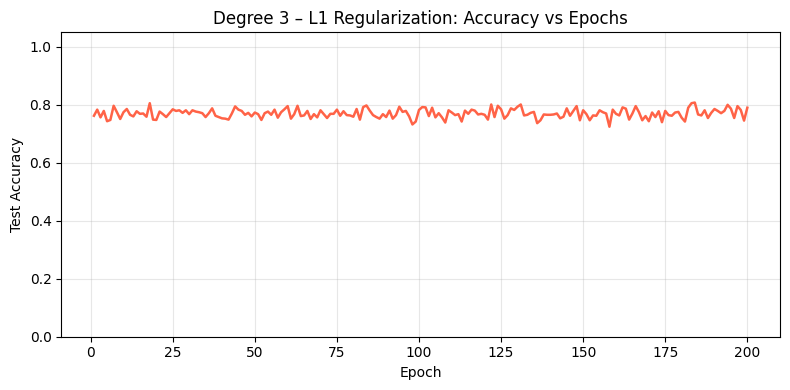

Final accuracy (L1, Degree 3): 0.7900


In [19]:
# ── Degree 3 – L1 Regularization (epoch by epoch) ───────────────────────────
clf_l1_3 = LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                               warm_start=True, max_iter=1)
acc_l1_3 = []

for epoch in range(n_epochs):
    clf_l1_3.fit(X_train_s3, y_train)
    acc_l1_3.append(accuracy_score(y_test, clf_l1_3.predict(X_test_s3)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), acc_l1_3, color='tomato', linewidth=1.8)
plt.title('Degree 3 – L1 Regularization: Accuracy vs Epochs')
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Final accuracy (L1, Degree 3): {acc_l1_3[-1]:.4f}')


### Degree 3 – L2 Regularization

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

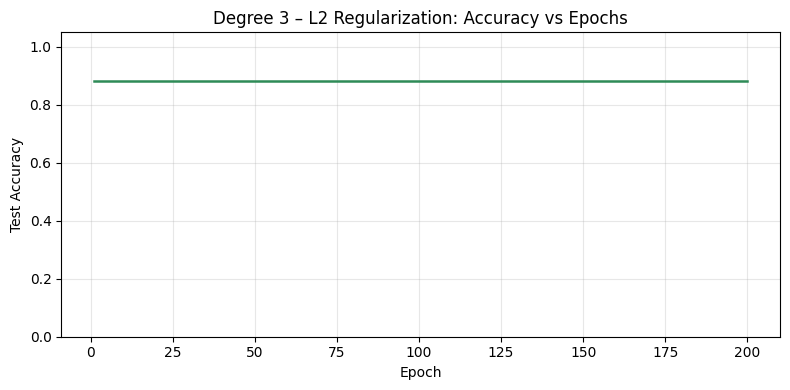

Final accuracy (L2, Degree 3): 0.8811


In [20]:
# ── Degree 3 – L2 Regularization (epoch by epoch) ───────────────────────────
clf_l2_3 = LogisticRegression(penalty='l2', C=1.0, solver='liblinear',
                               warm_start=True, max_iter=1)
acc_l2_3 = []

for epoch in range(n_epochs):
    clf_l2_3.fit(X_train_s3, y_train)
    acc_l2_3.append(accuracy_score(y_test, clf_l2_3.predict(X_test_s3)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), acc_l2_3, color='seagreen', linewidth=1.8)
plt.title('Degree 3 – L2 Regularization: Accuracy vs Epochs')
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Final accuracy (L2, Degree 3): {acc_l2_3[-1]:.4f}')
